In [2]:
# === Cell 1: setup + load the raw CUAD dataset ===
import os, sys, json, random, time
from collections import defaultdict, Counter
from pathlib import Path

import numpy as np
import torch

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# Device
if torch.cuda.is_available():
    DEVICE = 'cuda'
elif torch.backends.mps.is_available():
    DEVICE = 'mps'
else:
    DEVICE = 'cpu'

from datasets import load_dataset
raw = load_dataset("theatticusproject/cuad", verification_mode="no_checks")

raw

Resolving data files:   0%|          | 0/714 [00:00<?, ?it/s]

DatasetDict({
    train: Dataset({
        features: ['pdf'],
        num_rows: 511
    })
})

In [3]:
# === Cell 2: list the files actually in the CUAD dataset repo ===
from huggingface_hub import list_repo_files

files = list_repo_files("theatticusproject/cuad", repo_type="dataset")
for f in sorted(files):
    if not f.lower().endswith(".pdf"):     # hide the 511 raw PDFs
        print(f)

.gitattributes
CUAD_v1/CUAD v1 ReadMe _ Datasheet/CUAD_v1_README.txt
CUAD_v1/CUAD_v1.json
CUAD_v1/full_contract_txt/Part_I/ABILITYINC_06_15_2020-EX-4.25-SERVICES AGREEMENT.txt
CUAD_v1/full_contract_txt/Part_I/ACCURAYINC_09_01_2010-EX-10.31-DISTRIBUTOR AGREEMENT.txt
CUAD_v1/full_contract_txt/Part_I/ADAMSGOLFINC_03_21_2005-EX-10.17-ENDORSEMENT AGREEMENT.txt
CUAD_v1/full_contract_txt/Part_I/AIRSPANNETWORKSINC_04_11_2000-EX-10.5-Distributor Agreement.txt
CUAD_v1/full_contract_txt/Part_I/AMBASSADOREYEWEARGROUPINC_11_17_1997-EX-10.28-ENDORSEMENT AGREEMENT.txt
CUAD_v1/full_contract_txt/Part_I/AMERICANPHYSICIANSCAPITALINC_03_31_2003-EX-10.26-AGENCY AGREEMENT.txt
CUAD_v1/full_contract_txt/Part_I/AMERICASSHOPPINGMALLINC_12_10_1999-EX-10.2-SITE DEVELOPMENT AND HOSTING AGREEMENT.txt
CUAD_v1/full_contract_txt/Part_I/ANIXABIOSCIENCESINC_06_09_2020-EX-10.1-COLLABORATION AGREEMENT.txt
CUAD_v1/full_contract_txt/Part_I/ASPIRITYHOLDINGSLLC_05_07_2012-EX-10.6-OUTSOURCING AGREEMENT.txt
CUAD_v1/full_contrac

In [4]:
# === Cell 3: download the master clauses CSV, load with pandas, show shape ===
import pandas as pd
from huggingface_hub import hf_hub_download

csv_path = hf_hub_download(
    repo_id="theatticusproject/cuad",
    repo_type="dataset",
    filename="CUAD_v1/master_clauses.csv",
)

df = pd.read_csv(csv_path)
df.shape

(510, 83)

In [5]:
# === Cell 4: list all column names ===
for i, col in enumerate(df.columns):
    print(f"{i:2d}  {col}")

 0  Filename
 1  Document Name
 2  Document Name-Answer
 3  Parties
 4  Parties-Answer
 5  Agreement Date
 6  Agreement Date-Answer
 7  Effective Date
 8  Effective Date-Answer
 9  Expiration Date
10  Expiration Date-Answer
11  Renewal Term
12  Renewal Term-Answer
13  Notice Period To Terminate Renewal
14  Notice Period To Terminate Renewal- Answer
15  Governing Law
16  Governing Law-Answer
17  Most Favored Nation
18  Most Favored Nation-Answer
19  Competitive Restriction Exception
20  Competitive Restriction Exception-Answer
21  Non-Compete
22  Non-Compete-Answer
23  Exclusivity
24  Exclusivity-Answer
25  No-Solicit Of Customers
26  No-Solicit Of Customers-Answer
27  No-Solicit Of Employees
28  No-Solicit Of Employees-Answer
29  Non-Disparagement
30  Non-Disparagement-Answer
31  Termination For Convenience
32  Termination For Convenience-Answer
33  Rofr/Rofo/Rofn
34  Rofr/Rofo/Rofn-Answer
35  Change Of Control
36  Change Of Control-Answer
37  Anti-Assignment
38  Anti-Assignment-Answer

In [6]:
# === Cell 5: inspect the value format of a clause-text column and its answer column ===
cat = "Non-Compete"
sample = df[["Filename", cat, cat + "-Answer"]].head(4)

for _, row in sample.iterrows():
    print("Filename     :", row["Filename"][:50])
    print("  clause text:", repr(row[cat])[:160])
    print("  answer     :", repr(row[cat + "-Answer"]))
    print()

print("--- unique values in 'Non-Compete-Answer' ---")
print(df["Non-Compete-Answer"].value_counts(dropna=False))

Filename     : CybergyHoldingsInc_20140520_10-Q_EX-10.27_8605784_
  clause text: '[]'
  answer     : 'No'

Filename     : EuromediaHoldingsCorp_20070215_10SB12G_EX-10.B(01)
  clause text: '[]'
  answer     : 'No'

Filename     : FulucaiProductionsLtd_20131223_10-Q_EX-10.9_836834
  clause text: '[]'
  answer     : 'No'

Filename     : GopageCorp_20140221_10-K_EX-10.1_8432966_EX-10.1_C
  clause text: '[]'
  answer     : 'No'

--- unique values in 'Non-Compete-Answer' ---
Non-Compete-Answer
No     391
Yes    119
Name: count, dtype: int64


In [7]:
# === Cell 6: melt the wide table into long (contract, category) rows ===
import ast

def parse_spans(cell):
    """'[]' -> [] ;  "['clause a', 'clause b']" -> ['clause a','clause b'] ; NaN -> []"""
    if pd.isna(cell):
        return []
    try:
        val = ast.literal_eval(cell)
    except (ValueError, SyntaxError):
        s = str(cell).strip()
        return [s] if s and s != "[]" else []
    if isinstance(val, list):
        return [str(x).strip() for x in val if str(x).strip()]
    s = str(val).strip()
    return [s] if s else []

n_cat = (len(df.columns) - 1) // 2     # 41
records = []
for _, row in df.iterrows():
    for i in range(n_cat):
        text_col = df.columns[1 + 2 * i]   # clause text  (odd index)
        ans_col  = df.columns[2 + 2 * i]   # answer       (even index)
        spans = parse_spans(row[text_col])
        records.append({
            "filename": row["Filename"],
            "category": text_col,
            "answer"  : row[ans_col],
            "spans"   : spans,
            "n_spans" : len(spans),
            "present" : 1 if spans else 0,
        })

df_long = pd.DataFrame(records)
df_long.shape

(20910, 6)

In [8]:
# === Cell 7: look at the melted long table ===
df_long.head(10)

,filename,category,answer,spans,n_spans,present
0,CybergyHoldingsInc_20140520_10-Q_EX-10.27_8605...,Document Name,MARKETING AFFILIATE AGREEMENT,[MARKETING AFFILIATE AGREEMENT],1,1
1,CybergyHoldingsInc_20140520_10-Q_EX-10.27_8605...,Parties,"Birch First Global Investments Inc. (""Company""...","[BIRCH FIRST GLOBAL INVESTMENTS INC., MA, Mark...",5,1
2,CybergyHoldingsInc_20140520_10-Q_EX-10.27_8605...,Agreement Date,5/8/14,"[8th day of May 2014, May 8, 2014]",2,1
3,CybergyHoldingsInc_20140520_10-Q_EX-10.27_8605...,Effective Date,NaN,[This agreement shall begin upon the date of i...,1,1
4,CybergyHoldingsInc_20140520_10-Q_EX-10.27_8605...,Expiration Date,12/31/14,[This agreement shall begin upon the date of i...,1,1
5,CybergyHoldingsInc_20140520_10-Q_EX-10.27_8605...,Renewal Term,successive 1 year,[This agreement shall begin upon the date of i...,1,1
6,CybergyHoldingsInc_20140520_10-Q_EX-10.27_8605...,Notice Period To Terminate Renewal,30 days,[This Agreement may be terminated by either pa...,1,1
7,CybergyHoldingsInc_20140520_10-Q_EX-10.27_8605...,Governing Law,Nevada,[This Agreement is accepted by Company in the ...,1,1
8,CybergyHoldingsInc_20140520_10-Q_EX-10.27_8605...,Most Favored Nation,No,[],0,0
9,CybergyHoldingsInc_20140520_10-Q_EX-10.27_8605...,Competitive Restriction Exception,No,[],0,0


In [9]:
# === Cell 8: per-category positive rate from the melted table ===
rate = (
    df_long.groupby("category")["present"]
    .mean()
    .sort_values(ascending=False)
)
rate.to_frame("positive_rate").style.format({"positive_rate": "{:.1%}"})

,positive_rate
category,
Document Name,100.0%
Parties,99.8%
Agreement Date,92.2%
Governing Law,85.7%
Expiration Date,81.0%
Effective Date,76.5%
Anti-Assignment,73.3%
Cap On Liability,53.9%
License Grant,50.0%


In [10]:
# === Cell 9: load CUAD_v1.json (full context + char offsets for span training) ===
json_path = hf_hub_download(
    repo_id="theatticusproject/cuad",
    repo_type="dataset",
    filename="CUAD_v1/CUAD_v1.json",
)

with open(json_path) as f:
    cuad_json = json.load(f)

js = cuad_json["data"]
ex_qa = js[0]["paragraphs"][0]["qas"][0]
print("contracts in JSON :", len(js))
print("context present   :", "context" in js[0]["paragraphs"][0],
      "| context chars:", len(js[0]["paragraphs"][0]["context"]))
print("answer has offset :", "answer_start" in (ex_qa["answers"][0] if ex_qa["answers"] else {}))

contracts in JSON : 510
context present   : True | context chars: 54290
answer has offset : True


In [11]:
# === Cell 10: contract-level train/test split (80/20, by whole contract) ===
titles = [c["title"] for c in js]

rng = np.random.default_rng(SEED)
perm = rng.permutation(len(titles))
n_test = int(0.20 * len(titles))
test_set  = {titles[i] for i in perm[:n_test]}

train_titles = [t for t in titles if t not in test_set]
test_titles  = [t for t in titles if t in test_set]

print("total contracts :", len(titles))
print("train contracts :", len(train_titles))
print("test  contracts :", len(test_titles))

total contracts : 510
train contracts : 408
test  contracts : 102


In [12]:
# === Cell 11: presence dataset — labels per (contract, category), full text kept per contract ===
def cat_from_qid(qid):
    return qid.rsplit("__", 1)[-1]

ctx_by_title = {}                      # title -> full contract text (stored once, ~510 entries)
presence = []
for c in js:
    title = c["title"]
    split = "test" if title in test_set else "train"
    para = c["paragraphs"][0]
    ctx_by_title[title] = para["context"]
    for qa in para["qas"]:
        presence.append({
            "title"   : title,
            "category": cat_from_qid(qa["id"]),
            "question": qa["question"],
            "label"   : 1 if qa["answers"] else 0,
            "split"   : split,
        })

pres_df = pd.DataFrame(presence)
pres_df.groupby("split")["label"].agg(count="count", positive_rate="mean")

,count,positive_rate
split,,
test,4182,0.322334
train,16728,0.320062


In [13]:
# === Cell 12: baseline — TF-IDF over the FULL contract + per-category LogReg ===
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, precision_score, recall_score

_train = set(train_titles)
_test  = set(test_titles)
tr_titles = [t for t in titles if t in _train]
te_titles = [t for t in titles if t in _test]

vec = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), sublinear_tf=True, min_df=2)
X_train = vec.fit_transform([ctx_by_title[t] for t in tr_titles])
X_test  = vec.transform([ctx_by_title[t] for t in te_titles])

cats = sorted(pres_df["category"].unique())
lab = pres_df.pivot_table(index="title", columns="category", values="label", aggfunc="max")
Y_train = lab.loc[tr_titles, cats].values
Y_test  = lab.loc[te_titles, cats].values

rows = []
for j, cat in enumerate(cats):
    ytr, yte = Y_train[:, j], Y_test[:, j]
    if np.unique(ytr).size < 2:
        # Only one class in train (e.g. Document Name = always present) -> predict the constant.
        pred = np.full_like(yte, int(ytr[0]))
    else:
        clf = LogisticRegression(max_iter=1000, class_weight="balanced")
        clf.fit(X_train, ytr)
        pred = clf.predict(X_test)
    rows.append({
        "category" : cat,
        "test_pos" : int(yte.sum()),
        "precision": round(precision_score(yte, pred, zero_division=0), 3),
        "recall"   : round(recall_score(yte, pred, zero_division=0), 3),
        "f1"       : round(f1_score(yte, pred, zero_division=0), 3),
    })

base = pd.DataFrame(rows)
macro = pd.DataFrame([{
    "category": "** MACRO AVG **",
    "test_pos": int(base["test_pos"].sum()),
    "precision": round(base["precision"].mean(), 3),
    "recall"   : round(base["recall"].mean(), 3),
    "f1"       : round(base["f1"].mean(), 3),
}])
pd.concat([macro, base.sort_values("f1", ascending=False)], ignore_index=True)

,category,test_pos,precision,recall,f1
0,** MACRO AVG **,1348,0.551,0.619,0.572
1,Document Name,102,1.000,1.000,1.000
2,Parties,101,0.990,1.000,0.995
3,Governing Law,90,0.956,0.967,0.961
4,Agreement Date,93,0.929,0.989,0.958
5,Expiration Date,84,0.914,0.881,0.897
6,License Grant,56,0.907,0.875,0.891
7,Anti-Assignment,74,0.831,0.932,0.879
8,Effective Date,73,0.831,0.877,0.853
9,Cap On Liability,62,0.879,0.823,0.850


In [14]:
# === Cell 13: richer baseline anchors — micro, weighted, and tiered macro-F1 ===
P = np.zeros_like(Y_test)
for j in range(len(cats)):
    ytr = Y_train[:, j]
    if np.unique(ytr).size < 2:
        P[:, j] = int(ytr[0])
    else:
        clf = LogisticRegression(max_iter=1000, class_weight="balanced").fit(X_train, ytr)
        P[:, j] = clf.predict(X_test)

supp   = Y_test.sum(0)
common = supp >= 10
summary = pd.DataFrame([
    {"metric": "micro-F1  (all 3,116 cells equal)",
     "value": round(f1_score(Y_test.ravel(), P.ravel(), zero_division=0), 3)},
    {"metric": "weighted-F1  (by support)",
     "value": round(f1_score(Y_test, P, average="weighted", zero_division=0), 3)},
    {"metric": "macro-F1  (all 41 categories)",
     "value": round(f1_score(Y_test, P, average="macro", zero_division=0), 3)},
    {"metric": f"macro-F1  (>=10 test pos, {int(common.sum())} cats)",
     "value": round(f1_score(Y_test[:, common], P[:, common], average="macro", zero_division=0), 3)},
])
summary

,metric,value
0,"micro-F1 (all 3,116 cells equal)",0.775
1,weighted-F1 (by support),0.777
2,macro-F1 (all 41 categories),0.572
3,"macro-F1 (>=10 test pos, 34 cats)",0.666


In [15]:
# === Cell 14: sliding windows + question-guided retrieval (TF-IDF cosine) ===
from sklearn.metrics.pairwise import linear_kernel

WIN, STRIDE = 2000, 1500          # 2000-char windows, 500 overlap

windows_by_title = {}
for title, text in ctx_by_title.items():
    wins, pos = [], 0
    while pos < len(text):
        wins.append(text[pos:pos + WIN])
        if pos + WIN >= len(text):
            break
        pos += STRIDE
    windows_by_title[title] = wins or [text]

all_windows = [w for ws in windows_by_title.values() for w in ws]
retr_vec = TfidfVectorizer(max_features=30000, ngram_range=(1, 2),
                           min_df=2, sublinear_tf=True).fit(all_windows)

# query per category = the category's QUESTION text (inference-available, no answer peeking)
cat_question  = pres_df.groupby("category")["question"].first().to_dict()
cat_query_vec = {c: retr_vec.transform([cat_question[c]]) for c in cats}

def retrieve_window(title, category):
    wins = windows_by_title[title]
    scores = linear_kernel(cat_query_vec[category], retr_vec.transform(wins)).ravel()
    return wins[int(scores.argmax())]

# --- sanity check: does the retrieved window actually contain the gold clause? ---
demo_t, demo_cat = train_titles[0], "Audit Rights"
win = retrieve_window(demo_t, demo_cat)
qa = next(q for q in next(c for c in js if c["title"] == demo_t)["paragraphs"][0]["qas"]
          if cat_from_qid(q["id"]) == demo_cat)
gold = qa["answers"][0]["text"] if qa["answers"] else None
print("contract         :", demo_t[:55])
print("category         :", demo_cat, "| gold present:", gold is not None)
print("retrieved window :", win[:200].replace("\n", " "))
if gold:
    print("gold in window?  :", gold[:60] in win)

contract         : WHITESMOKE,INC_11_08_2011-EX-10.26-PROMOTION AND DISTRI
category         : Audit Rights | gold present: True
retrieved window :     (iii) [ * ]: (A) are determined on a [ * ]; (B) are only [ * ]; (C) are not sent in response to [ * ] from computers on which  another [ * ] of the [ * ] is [ * ]; and (D) are sent only in respons
gold in window?  : True


In [16]:
# === Cell 15: apply retrieval to all rows + measure hit-rate on positives ===
# Precompute each contract's window TF-IDF matrix ONCE (avoid re-vectorizing 41x)
win_mat = {t: retr_vec.transform(ws) for t, ws in windows_by_title.items()}

def best_window_idx(title, category):
    scores = linear_kernel(cat_query_vec[category], win_mat[title]).ravel()
    return int(scores.argmax())

# gold span per (title, category) — used ONLY to score retrieval quality, never to build the window
gold_by_key = {}
for c in js:
    t = c["title"]
    for qa in c["paragraphs"][0]["qas"]:
        gold_by_key[(t, cat_from_qid(qa["id"]))] = (
            qa["answers"][0]["text"] if qa["answers"] else None
        )

t0 = time.time()
windows_col, hit, npos = [], 0, 0
for r in presence:                       # the list built in Cell 11
    t, cat = r["title"], r["category"]
    w = windows_by_title[t][best_window_idx(t, cat)]
    windows_col.append(w)
    g = gold_by_key[(t, cat)]
    if g:
        npos += 1
        hit += int(g[:80] in w)

pres_df["window"] = windows_col
print(f"applied retrieval to {len(pres_df):,} rows in {time.time()-t0:.1f}s")
print(f"retrieval hit-rate on positives : {hit}/{npos} = {hit/npos:.1%}")

applied retrieval to 20,910 rows in 2.2s
retrieval hit-rate on positives : 2005/6702 = 29.9%


In [17]:
# === Cell 16: fix retrieval — compare query = question vs category-name, top1 vs top3 ===
from collections import defaultdict

# all gold spans per (title, category)  [previously only kept the first]
gold_spans = defaultdict(list)
for c in js:
    t = c["title"]
    for qa in c["paragraphs"][0]["qas"]:
        cat = cat_from_qid(qa["id"])
        for a in qa["answers"]:
            if a["text"].strip():
                gold_spans[(t, cat)].append(a["text"])

def hit_rate(query_by_cat, topk=1):
    qv = {c: retr_vec.transform([query_by_cat[c]]) for c in cats}
    hit = npos = 0
    for (t, cat), spans in gold_spans.items():
        npos += 1
        scores = linear_kernel(qv[cat], win_mat[t]).ravel()
        top = scores.argsort()[::-1][:topk]
        joined = " ".join(windows_by_title[t][i] for i in top)
        hit += int(any(s[:80] in joined for s in spans))
    return hit / npos

strategies = [
    ("question        (top1)", cat_question,                              1),
    ("category name   (top1)", {c: c for c in cats},                      1),
    ("category name   (top3)", {c: c for c in cats},                      3),
    ("name+question   (top3)", {c: c + " " + cat_question[c] for c in cats}, 3),
]
pd.DataFrame([{"strategy": s, "topk": k, "hit_rate": round(hit_rate(q, k), 3)}
              for s, q, k in strategies])

,strategy,topk,hit_rate
0,question (top1),1,0.386
1,category name (top1),1,0.446
2,category name (top3),3,0.640
3,name+question (top3),3,0.615


In [18]:
# === Cell 17: build window-level training examples (MIL, TRAIN split only) ===
import random as _random
_random.seed(SEED)

def has_span(spans, w):
    return any(s[:80] in w for s in spans)

NEG_PER_BAG = 2     # sampled negative windows per (contract, category)

win_examples = []
for c in js:
    title = c["title"]
    if title not in _train:                      # TRAIN ONLY
        continue
    wins = windows_by_title[title]
    for qa in c["paragraphs"][0]["qas"]:
        cat   = cat_from_qid(qa["id"])
        q     = qa["question"]
        spans = gold_spans.get((title, cat), [])
        if spans:                                 # present
            pos_idx = [i for i, w in enumerate(wins) if has_span(spans, w)]
            neg_idx = [i for i in range(len(wins)) if i not in pos_idx]
            for i in pos_idx:
                win_examples.append({"question": q, "window": wins[i], "label": 1})
            for i in _random.sample(neg_idx, min(NEG_PER_BAG, len(neg_idx))):
                win_examples.append({"question": q, "window": wins[i], "label": 0})
        else:                                     # absent — all windows negative
            for i in _random.sample(range(len(wins)), min(NEG_PER_BAG, len(wins))):
                win_examples.append({"question": q, "window": wins[i], "label": 0})

win_df = pd.DataFrame(win_examples)
pd.DataFrame({
    "n_examples":    [len(win_df)],
    "positives":     [int(win_df["label"].sum())],
    "positive_rate": [round(win_df["label"].mean(), 3)],
})

,n_examples,positives,positive_rate
0,53662,21028,0.392


In [19]:
# === Cell 18: train window-level DistilBERT (question, window) -> contains-clause ===
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          DataCollatorWithPadding, Trainer, TrainingArguments)
from datasets import Dataset

MODEL_NAME = "distilbert-base-uncased"
MAX_LEN, BATCH, EPOCHS, LR = 256, 16, 2, 2e-5
MAX_TRAIN = 24000          # subsample cap (keep ~39% positive). Raise for more data / more time.

# stratified subsample to keep training tractable on a laptop
if len(win_df) > MAX_TRAIN:
    win_df_s = (win_df.groupby("label", group_keys=False)
                .apply(lambda g: g.sample(round(MAX_TRAIN * len(g) / len(win_df)),
                                          random_state=SEED)))
else:
    win_df_s = win_df
print("training on", len(win_df_s), "examples | positive rate",
      round(win_df_s["label"].mean(), 3))

tok = AutoTokenizer.from_pretrained(MODEL_NAME)
wds = Dataset.from_pandas(win_df_s[["question", "window", "label"]], preserve_index=False).shuffle(seed=SEED)
wsplit = wds.train_test_split(test_size=0.05, seed=SEED)

def enc(b):
    e = tok(b["question"], b["window"], truncation=True, max_length=MAX_LEN)
    e["labels"] = b["label"]
    return e

wtr = wsplit["train"].map(enc, batched=True, remove_columns=wsplit["train"].column_names)
wva = wsplit["test"].map(enc,  batched=True, remove_columns=wsplit["test"].column_names)

mil_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

args = TrainingArguments(
    output_dir="outputs/presence_mil/ckpt",
    num_train_epochs=EPOCHS, per_device_train_batch_size=BATCH,
    per_device_eval_batch_size=BATCH, learning_rate=LR,
    eval_strategy="epoch", logging_strategy="steps", logging_steps=100,
    save_strategy="no", report_to="none", seed=SEED,
    fp16=False, bf16=False, dataloader_pin_memory=False,
)
mil_trainer = Trainer(model=mil_model, args=args, train_dataset=wtr, eval_dataset=wva,
                      processing_class=tok, data_collator=DataCollatorWithPadding(tok))

t0 = time.time()
mil_trainer.train()
print(f"\n[done] window-level training took {(time.time()-t0)/60:.1f} min")

/var/folders/f2/k9ltmsyj2p7cp8zk2c6w7smm0000gn/T/ipykernel_6773/460527326.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(round(MAX_TRAIN * len(g) / len(win_df)),


training on 24000 examples | positive rate 0.392


Map:   0%|          | 0/22800 [00:00<?, ? examples/s]

Map:   0%|          | 0/1200 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss
1,0.316910,0.282235
2,0.262822,0.253757



[done] window-level training took 52.4 min


In [20]:
# === Cell 19: max-pool inference over ALL test windows, compare to TF-IDF baseline ===
import torch, torch.nn.functional as F

# every (question, window) pair for the TEST contracts
test_pairs = []
for c in js:
    title = c["title"]
    if title not in _test:
        continue
    wins = windows_by_title[title]
    for qa in c["paragraphs"][0]["qas"]:
        cat, q = cat_from_qid(qa["id"]), qa["question"]
        for w in wins:
            test_pairs.append((title, cat, q, w))

test_pd = pd.DataFrame(test_pairs, columns=["title", "category", "question", "window"])

def enc_infer(b):
    return tok(b["question"], b["window"], truncation=True, max_length=MAX_LEN)

test_ds  = Dataset.from_pandas(test_pd[["question", "window"]], preserve_index=False)
test_tok = test_ds.map(enc_infer, batched=True, remove_columns=test_ds.column_names)

pred  = mil_trainer.predict(test_tok)
test_pd["p1"] = F.softmax(torch.tensor(pred.predictions), dim=-1)[:, 1].numpy()

# max-pool over windows -> one prediction per (contract, category)
bag = test_pd.groupby(["title", "category"])["p1"].max().reset_index()
bag["pred"] = (bag["p1"] >= 0.5).astype(int)
bag["true"] = [int(bool(gold_spans.get((t, c), [])))
               for t, c in zip(bag["title"], bag["category"])]

rows = []
for cat in cats:
    sub = bag[bag["category"] == cat]
    yt, yp = sub["true"].values, sub["pred"].values
    if yt.sum() == 0:
        continue
    rows.append({"category": cat, "test_pos": int(yt.sum()),
                 "mil_f1": round(f1_score(yt, yp, zero_division=0), 3)})
mil = pd.DataFrame(rows)

micro = f1_score(bag["true"], bag["pred"], zero_division=0)
per = (mil.merge(base[["category", "f1"]].rename(columns={"f1": "baseline_f1"}), on="category"))
per["delta"] = (per["mil_f1"] - per["baseline_f1"]).round(3)
per = per[["category", "test_pos", "baseline_f1", "mil_f1", "delta"]]

head = pd.DataFrame([{"category": "** MICRO-F1 (all bags) **",
                      "test_pos": int(bag["true"].sum()),
                      "baseline_f1": 0.776, "mil_f1": round(micro, 3),
                      "delta": round(micro - 0.776, 3)}])
pd.concat([head, per.sort_values("delta", ascending=False)], ignore_index=True)

Map:   0%|          | 0/150224 [00:00<?, ? examples/s]

,category,test_pos,baseline_f1,mil_f1,delta
0,** MICRO-F1 (all bags) **,1348,0.776,0.700,-0.076
1,Unlimited/All-You-Can-Eat-License,2,0.000,0.667,0.667
2,No-Solicit Of Customers,6,0.000,0.267,0.267
3,No-Solicit Of Employees,17,0.529,0.634,0.105
4,Price Restrictions,4,0.000,0.100,0.100
5,Competitive Restriction Exception,17,0.400,0.478,0.078
6,Liquidated Damages,11,0.240,0.308,0.068
7,Joint Ip Ownership,8,0.381,0.412,0.031
8,Expiration Date,84,0.897,0.914,0.017
9,Non-Compete,25,0.577,0.590,0.013


In [22]:
# === Cell 20: ensemble TF-IDF + transformer (parameter-free) vs each alone ===
# 1) TF-IDF probability per (test contract, category)
proba_tfidf = np.zeros_like(Y_test, dtype=float)
for j in range(len(cats)):
    ytr = Y_train[:, j]
    if np.unique(ytr).size < 2:
        proba_tfidf[:, j] = float(ytr[0])
    else:
        clf = LogisticRegression(max_iter=1000, class_weight="balanced").fit(X_train, ytr)
        proba_tfidf[:, j] = clf.predict_proba(X_test)[:, 1]

p_tfidf = {(te_titles[i], cats[j]): proba_tfidf[i, j]
           for i in range(len(te_titles)) for j in range(len(cats))}

# 2) transformer max-pool probability per (title, category) — from Cell 19 `bag`
p_trans = {(t, c): p for t, c, p in zip(bag["title"], bag["category"], bag["p1"])}

# 3) align + true labels
keys = list(p_tfidf.keys())
a = np.array([p_tfidf[k]            for k in keys])   # TF-IDF prob
b = np.array([p_trans.get(k, 0.0)  for k in keys])   # transformer prob
y = np.array([int(bool(gold_spans.get(k, []))) for k in keys])

micro = lambda pred: round(f1_score(y, pred, zero_division=0), 3)

results = pd.DataFrame([
    {"model": "TF-IDF baseline",         "micro_F1": micro((a >= 0.5).astype(int))},
    {"model": "Transformer (max-pool)",  "micro_F1": micro((b >= 0.5).astype(int))},
    {"model": "Ensemble AVG  (mean)",    "micro_F1": micro(((a + b) / 2 >= 0.5).astype(int))},
    {"model": "Ensemble OR   (max)",     "micro_F1": micro((np.maximum(a, b) >= 0.5).astype(int))},
    {"model": "Ensemble AND  (min)",     "micro_F1": micro((np.minimum(a, b) >= 0.5).astype(int))},
])
results.sort_values("micro_F1", ascending=False).reset_index(drop=True)

,model,micro_F1
0,Ensemble AND (min),0.781
1,TF-IDF baseline,0.775
2,Ensemble AVG (mean),0.722
3,Transformer (max-pool),0.700
4,Ensemble OR (max),0.697


CONFUSION MATRIX (AND-ensemble, 80/20 test set)
                 Predicted Absent   Predicted Present
Actually Absent      TN =  2533         FP =   301
Actually Present     FN =   291         TP =  1057

TEST METRICS (from the confusion matrix):
  Accuracy    : 0.8584
  Precision   : 0.7784
  Recall      : 0.7841
  Specificity : 0.8938
  F1 Score    : 0.7812



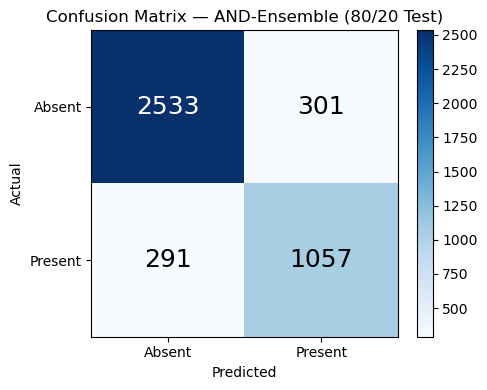

In [24]:
# === Cell 20B: confusion matrix + classification report (AND-ensemble, 80/20 test) ===
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

# a = TF-IDF probs, b = transformer probs, y = true labels (from Cell 20)
y_pred = (np.minimum(a, b) >= 0.5).astype(int)

cm = confusion_matrix(y, y_pred)
tn, fp, fn, tp = cm.ravel()

print("=" * 50)
print("CONFUSION MATRIX (AND-ensemble, 80/20 test set)")
print("=" * 50)
print(f"                 Predicted Absent   Predicted Present")
print(f"Actually Absent      TN = {tn:>5d}         FP = {fp:>5d}")
print(f"Actually Present     FN = {fn:>5d}         TP = {tp:>5d}")
print()

acc  = (tp + tn) / (tp + tn + fp + fn)
prec = tp / (tp + fp) if (tp + fp) > 0 else 0
rec  = tp / (tp + fn) if (tp + fn) > 0 else 0
spec = tn / (tn + fp) if (tn + fp) > 0 else 0
f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0

print("TEST METRICS (from the confusion matrix):")
print(f"  Accuracy    : {acc:.4f}")
print(f"  Precision   : {prec:.4f}")
print(f"  Recall      : {rec:.4f}")
print(f"  Specificity : {spec:.4f}")
print(f"  F1 Score    : {f1:.4f}")
print()

# --- heatmap ---
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]}", ha="center", va="center",
                fontsize=18, color="white" if cm[i, j] > cm.max()/2 else "black")
ax.set_xticks([0, 1]); ax.set_xticklabels(["Absent", "Present"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["Absent", "Present"])
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix — AND-Ensemble (80/20 Test)")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

In [25]:
# === Cell 21: build span-extraction examples (present clauses only, windowed) ===
span_examples = []
for c in js:
    title = c["title"]
    split = "test" if title in _test else "train"
    wins  = windows_by_title[title]
    for qa in c["paragraphs"][0]["qas"]:
        if not qa["answers"]:
            continue
        cat, q = cat_from_qid(qa["id"]), qa["question"]
        for a in qa["answers"]:
            atext = a["text"].strip()
            if not atext:
                continue
            probe = atext[:200]                 # match on first 200 chars
            for w in wins:
                pos = w.find(probe)
                if pos != -1:
                    span_examples.append({
                        "title": title, "split": split, "category": cat,
                        "question": q, "context": w,
                        "answer_text": atext, "char_start": pos,
                    })
                    break

span_df = pd.DataFrame(span_examples)
span_df.groupby("split").size().to_frame("n_examples")

,n_examples
split,
test,2667
train,11156


In [26]:
# === Cell 22: tokenize span examples -> (start_token, end_token) labels ===
QA_MODEL, QA_MAXLEN, FOCUS, MAX_SPAN_TRAIN = "distilbert-base-uncased", 320, 1200, 8000
qa_tok = AutoTokenizer.from_pretrained(QA_MODEL)

def encode_qa(batch):
    ctxs, a_starts, a_ends = [], [], []
    for w, cs, at in zip(batch["context"], batch["char_start"], batch["answer_text"]):
        start_f = max(0, cs - 150)
        ctx = w[start_f:start_f + FOCUS]
        a_s = cs - start_f
        ctxs.append(ctx); a_starts.append(a_s); a_ends.append(min(len(ctx), a_s + len(at)))
    enc = qa_tok(batch["question"], ctxs, truncation="only_second",
                 max_length=QA_MAXLEN, return_offsets_mapping=True)
    starts, ends = [], []
    for i in range(len(ctxs)):
        off, seq = enc["offset_mapping"][i], enc.sequence_ids(i)
        idx = 0
        while seq[idx] != 1: idx += 1
        c_start = idx
        while idx < len(seq) and seq[idx] == 1: idx += 1
        c_end = idx - 1
        a_s, a_e = a_starts[i], a_ends[i]
        if off[c_start][0] > a_s or off[c_end][1] < a_e:
            ts = te = 0                                   # answer not in span -> CLS
        else:
            j = c_start
            while j <= c_end and off[j][0] <= a_s: j += 1
            ts = j - 1
            j = c_end
            while j >= c_start and off[j][1] >= a_e: j -= 1
            te = j + 1
        starts.append(ts); ends.append(te)
    enc["start_positions"], enc["end_positions"] = starts, ends
    enc.pop("offset_mapping")
    return enc

n_train = int((span_df["split"] == "train").sum())
sp_train = span_df[span_df.split == "train"].sample(min(MAX_SPAN_TRAIN, n_train), random_state=SEED)
sp_test  = span_df[span_df.split == "test"]

qa_train = Dataset.from_pandas(sp_train, preserve_index=False).map(
    encode_qa, batched=True, remove_columns=sp_train.columns.tolist())
qa_test = Dataset.from_pandas(sp_test, preserve_index=False).map(
    encode_qa, batched=True, remove_columns=sp_test.columns.tolist())

# sanity: decode the labelled span back to text for 3 examples (should match the gold answer start)
for i in range(3):
    s, e = qa_train[i]["start_positions"], qa_train[i]["end_positions"]
    print("label span ->", qa_tok.decode(qa_train[i]["input_ids"][s:e+1])[:90])

Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2667 [00:00<?, ? examples/s]

label span -> 3 - 31 - 16
label span -> wgt
label span -> 12th day of november, 2018


In [27]:
# === Cell 23: train DistilBertForQuestionAnswering (span extractor) ===
from transformers import AutoModelForQuestionAnswering

qa_model = AutoModelForQuestionAnswering.from_pretrained(QA_MODEL)

def qa_collator(features):
    batch = qa_tok.pad(
        {"input_ids":      [f["input_ids"]      for f in features],
         "attention_mask": [f["attention_mask"] for f in features]},
        padding=True, return_tensors="pt",
    )
    batch["start_positions"] = torch.tensor([f["start_positions"] for f in features])
    batch["end_positions"]   = torch.tensor([f["end_positions"]   for f in features])
    return batch

qa_args = TrainingArguments(
    output_dir="outputs/span/ckpt",
    num_train_epochs=2, per_device_train_batch_size=16,
    per_device_eval_batch_size=16, learning_rate=3e-5,
    logging_strategy="steps", logging_steps=100,
    eval_strategy="no", save_strategy="no", report_to="none", seed=SEED,
    fp16=False, bf16=False, dataloader_pin_memory=False,
)
qa_trainer = Trainer(model=qa_model, args=qa_args, train_dataset=qa_train,
                     processing_class=qa_tok, data_collator=qa_collator)

t0 = time.time()
qa_trainer.train()
print(f"\n[done] span training took {(time.time()-t0)/60:.1f} min")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForQuestionAnswering LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
qa_outputs.bias         | MISSING    | 
qa_outputs.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
100,2.775316
200,1.412806
300,1.232014
400,1.035019
500,0.923276
600,0.723134
700,0.698320
800,0.723565
900,0.661691
1000,0.660812



[done] span training took 23.0 min


In [28]:
# === Cell 24: evaluate span extractor — Exact Match + token-F1 on test ===
import re, string
from collections import Counter

def normalize(s):
    s = s.lower()
    s = re.sub(r"\b(a|an|the)\b", " ", s)
    s = "".join(ch for ch in s if ch not in string.punctuation)
    return " ".join(s.split())

def token_f1(pred, gold):
    p, g = normalize(pred).split(), normalize(gold).split()
    if not p or not g:
        return float(p == g)
    common = sum((Counter(p) & Counter(g)).values())
    if common == 0:
        return 0.0
    prec, rec = common / len(p), common / len(g)
    return 2 * prec * rec / (prec + rec)

preds = qa_trainer.predict(qa_test)
start_logits, end_logits = preds.predictions
golds = sp_test["answer_text"].tolist()
sep_id = qa_tok.sep_token_id

em = f1 = overlap = 0
N = len(qa_test)
for i in range(N):
    ids = qa_test[i]["input_ids"]
    sep = ids.index(sep_id)                       # end of the question
    mask = np.full(len(ids), -1e9); mask[sep + 1:] = 0.0
    s = int(np.argmax(start_logits[i][:len(ids)] + mask))
    e = int(np.argmax(end_logits[i][:len(ids)] + mask))
    if e < s: e = s
    e = min(e, s + 60)                            # cap span length
    pred_text = qa_tok.decode(ids[s:e + 1], skip_special_tokens=True)
    g = golds[i]
    em      += int(normalize(pred_text) == normalize(g))
    this_f1  = token_f1(pred_text, g)
    f1      += this_f1
    overlap += int(this_f1 >= 0.5)

print(f"span extractor on {N} test examples (answer-bearing windows):")
print(f"  Exact Match     : {em/N:.1%}")
print(f"  token-F1        : {f1/N:.3f}")
print(f"  overlap (F1>=.5): {overlap/N:.1%}")

span extractor on 2667 test examples (answer-bearing windows):
  Exact Match     : 35.3%
  token-F1        : 0.760
  overlap (F1>=.5): 82.5%


In [29]:
# === Cell A (after restart): minimal setup + rebuild summarizer data ===
import json, time, random
import numpy as np, pandas as pd, torch
from datasets import Dataset
from transformers import AutoTokenizer
from huggingface_hub import hf_hub_download

SEED = 42; random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

js = json.load(open(hf_hub_download("theatticusproject/cuad", repo_type="dataset",
                                    filename="CUAD_v1/CUAD_v1.json")))["data"]

titles = [c["title"] for c in js]
rng = np.random.default_rng(SEED)
test_set = {titles[i] for i in rng.permutation(len(titles))[:int(0.20 * len(titles))]}

GOLD_SUMMARIES = {
    "Document Name": "This states the official name and type of the agreement.",
    "Parties": "This identifies who is signing the contract and the role each side plays.",
    "Agreement Date": "This is the date the contract was signed.",
    "Effective Date": "This is the date the contract terms actually start applying.",
    "Expiration Date": "This is when the contract is scheduled to end.",
    "Renewal Term": "This explains how the contract continues if neither side cancels.",
    "Notice Period To Terminate Renewal": "This is how long ahead you must say you will not renew.",
    "Governing Law": "This says which country or state law decides any dispute.",
    "Most Favored Nation": "This promises you the best deal the other side gives anyone else.",
    "Non-Compete": "This restricts you from working with the other side's competitors.",
    "Exclusivity": "This makes one side the only allowed source or buyer for something.",
    "No-Solicit Of Customers": "You agree not to approach the other side's customers.",
    "Competitive Restriction Exception": "This lists where the non-compete or exclusivity does not apply.",
    "No-Solicit Of Employees": "You agree not to recruit the other side's employees.",
    "Non-Disparagement": "You agree not to publicly criticise the other side.",
    "Termination For Convenience": "Either side can end the contract for any reason with notice.",
    "Rofr/Rofo/Rofn": "You get the first chance to match an offer or take an opportunity.",
    "Change Of Control": "This explains what happens if one company is bought or merges.",
    "Anti-Assignment": "You cannot transfer this contract to someone else without permission.",
    "Revenue/Profit Sharing": "You share a portion of revenue or profit with the other side.",
    "Price Restrictions": "This limits what prices you can charge or change.",
    "Minimum Commitment": "You promise to buy or deliver at least a stated minimum amount.",
    "Volume Restriction": "There is a cap on how much you can sell or distribute.",
    "Ip Ownership Assignment": "Any new intellectual property created belongs to the named owner.",
    "Joint Ip Ownership": "Both sides jointly own intellectual property created under this contract.",
    "License Grant": "This grants permission to use the other side's intellectual property.",
    "Non-Transferable License": "You cannot pass this licence to anyone else.",
    "Affiliate License-Licensor": "The licensor's affiliates also grant you rights here.",
    "Affiliate License-Licensee": "Your affiliates can use the licence too.",
    "Unlimited/All-You-Can-Eat-License": "The licence is unlimited in scope or volume.",
    "Irrevocable Or Perpetual License": "The licence cannot be taken away and may last forever.",
    "Source Code Escrow": "Source code is held by a third party in case something goes wrong.",
    "Post-Termination Services": "Some services continue for a while after the contract ends.",
    "Audit Rights": "The other side can inspect your records to check compliance.",
    "Uncapped Liability": "There is no limit on how much one side may owe in damages.",
    "Cap On Liability": "There is a maximum amount one side may owe in damages.",
    "Liquidated Damages": "A fixed amount is owed for specific breaches, agreed in advance.",
    "Warranty Duration": "This is how long the warranty lasts.",
    "Insurance": "You must keep specified insurance coverage in force.",
    "Covenant Not To Sue": "You agree not to sue the other side over the listed matters.",
    "Third Party Beneficiary": "Someone not signing the contract still gets to enforce part of it.",
}
def cat_from_qid(q): return q.rsplit("__", 1)[-1]

rows = []
for c in js:
    split = "test" if c["title"] in test_set else "train"
    for qa in c["paragraphs"][0]["qas"]:
        s = GOLD_SUMMARIES.get(cat_from_qid(qa["id"]))
        if not s:
            continue
        for a in qa["answers"]:
            at = a["text"].strip()
            if at:
                rows.append({"split": split,
                             "input_text": f"summarize in plain English: {at[:1200]}",
                             "target_text": s})
sum_df = pd.DataFrame(rows)
sum_df.groupby("split").size().to_frame("n_pairs")

,n_pairs
split,
test,2667
train,11156


In [30]:
# === Cell B (CPU): fine-tune FLAN-T5-small without touching MPS ===
from transformers import (AutoModelForSeq2SeqLM, DataCollatorForSeq2Seq,
                          Seq2SeqTrainer, Seq2SeqTrainingArguments)
T5_MODEL, MAX_IN, MAX_OUT, MAX_SUM_TRAIN = "google/flan-t5-small", 256, 48, 4000

t5_tok   = AutoTokenizer.from_pretrained(T5_MODEL)
t5_model = AutoModelForSeq2SeqLM.from_pretrained(T5_MODEL)

n_tr    = int((sum_df.split == "train").sum())
s_train = sum_df[sum_df.split == "train"].sample(min(MAX_SUM_TRAIN, n_tr), random_state=SEED)
s_val   = sum_df[sum_df.split == "test"].sample(300, random_state=SEED)

def enc_sum(b):
    mi = t5_tok(b["input_text"], truncation=True, max_length=MAX_IN)
    mi["labels"] = t5_tok(text_target=b["target_text"], truncation=True, max_length=MAX_OUT)["input_ids"]
    return mi

t5_train = Dataset.from_pandas(s_train, preserve_index=False).map(
    enc_sum, batched=True, remove_columns=s_train.columns.tolist())
t5_val = Dataset.from_pandas(s_val, preserve_index=False).map(
    enc_sum, batched=True, remove_columns=s_val.columns.tolist())

t5_args = Seq2SeqTrainingArguments(
    output_dir="outputs/summarizer/ckpt", num_train_epochs=2,
    per_device_train_batch_size=8, per_device_eval_batch_size=8,
    learning_rate=3e-4, eval_strategy="epoch", logging_strategy="steps", logging_steps=100,
    save_strategy="no", report_to="none", seed=SEED,
    use_cpu=True,                          # <-- force CPU, dodge the MPS OOM
    fp16=False, bf16=False, dataloader_pin_memory=False,
)
t5_trainer = Seq2SeqTrainer(
    model=t5_model, args=t5_args, train_dataset=t5_train, eval_dataset=t5_val,
    processing_class=t5_tok, data_collator=DataCollatorForSeq2Seq(t5_tok, model=t5_model))

t0 = time.time()
t5_trainer.train()
print(f"\n[done] summarizer training took {(time.time()-t0)/60:.1f} min")

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss
1,0.141163,0.096197
2,0.084836,0.075160



[done] summarizer training took 7.8 min


In [31]:
# === Cell 27: summarizer ROUGE-L on test clauses ===
def lcs_len(a, b):
    dp = [0] * (len(b) + 1)
    for i in range(1, len(a) + 1):
        prev = 0
        for j in range(1, len(b) + 1):
            tmp = dp[j]
            dp[j] = prev + 1 if a[i - 1] == b[j - 1] else max(dp[j], dp[j - 1])
            prev = tmp
    return dp[-1]

def rouge_l(pred, gold):
    p, g = pred.lower().split(), gold.lower().split()
    if not p or not g:
        return 0.0
    l = lcs_len(p, g)
    if l == 0:
        return 0.0
    pr, rc = l / len(p), l / len(g)
    return 2 * pr * rc / (pr + rc)

t5_model.eval()
samp = sum_df[sum_df.split == "test"].sample(150, random_state=SEED).reset_index(drop=True)
scores = []
for i in range(len(samp)):
    inp = t5_tok(samp.loc[i, "input_text"], return_tensors="pt",
                 truncation=True, max_length=MAX_IN).to(t5_model.device)
    out = t5_model.generate(**inp, max_new_tokens=MAX_OUT, num_beams=2)
    scores.append(rouge_l(t5_tok.decode(out[0], skip_special_tokens=True),
                          samp.loc[i, "target_text"]))
print(f"fine-tuned summarizer ROUGE-L on 150 test clauses : {np.mean(scores):.3f}")

fine-tuned summarizer ROUGE-L on 150 test clauses : 0.785


In [33]:
# === Cell 28: zero-shot vs fine-tuned summarizer, same clauses ===
from transformers import AutoModelForSeq2SeqLM
zs_model = AutoModelForSeq2SeqLM.from_pretrained("google/flan-t5-small").to("cpu")
t5_model = t5_model.to("cpu")

demo = sum_df[sum_df.split == "test"].sample(4, random_state=1).reset_index(drop=True)
for i in range(len(demo)):
    clause = demo.loc[i, "input_text"].replace("summarize in plain English: ", "")
    enc = t5_tok(demo.loc[i, "input_text"], return_tensors="pt",
                 truncation=True, max_length=256)
    ft = t5_tok.decode(t5_model.generate(**enc, max_new_tokens=40)[0], skip_special_tokens=True)
    zs = t5_tok.decode(zs_model.generate(**enc, max_new_tokens=40)[0], skip_special_tokens=True)
    print(f"--- clause {i+1} ---")
    print("clause    :", clause[:160])
    print("gold      :", demo.loc[i, "target_text"])
    print("fine-tuned:", ft)
    print("zero-shot :", zs)
    print()

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


--- clause 1 ---
clause    : New Process Technologies that have been developed by Eutectix, alone or with a third party, shall be solely owned by Eutectix, and, if permitted, Eutectix shall
gold      : This grants permission to use the other side's intellectual property.
fine-tuned: This grants permission to use the other side's intellectual property.
zero-shot : New Process Technologies that have been developed by Eutectix, alone or with a third party, shall be solely owned by Eutectix and, if permitted, Eutect

--- clause 2 ---
clause    : KPN Telecom B.V.
gold      : This identifies who is signing the contract and the role each side plays.
fine-tuned: This identifies who is signing the contract and the role each side plays.
zero-shot : KPN Telecom B.V.

--- clause 3 ---
clause    : PaperExchange hereby grants VerticalNet an exclusive license to use, modify, enhance, reproduce, display, perform and transmit the PaperExchange Content, subjec
gold      : This grants permission to use t